In [13]:
from lcdb.db import LCDB
from lcdb.analysis.util import LearningCurve, LearningCurveGroup, LearningCurveExtractor, merge_curves

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

import itertools as it
import pathlib

In [20]:
def plot_successive_halving(openmlid, workflow, test_seed=0, survival_factor = 0.5, y_lim=None):

    # retrieve learning curve objects
    lcdb = LCDB()
    df_full = lcdb.query(
        openmlids=[openmlid],
        workflows=[workflow],
        test_seeds=[test_seed],
        return_generator=False,
        processors={
            "learning_curve": LearningCurveExtractor(
                metrics=["error_rate"],
                folds=["val"]
            )
        },
        show_progress=True
    )
    config_cols = [c for c in df_full.columns if c.startswith("p:")]
    df_grouped = df_full.groupby(config_cols).agg({"learning_curve": merge_curves})
    lcg = LearningCurveGroup(list(df_grouped["learning_curve"]))
    lcs = np.array([np.nanmean(lc[0, 0], axis=(0, 1, 2)) for lc in lcg])
    schedule = df_grouped.iloc[0]["learning_curve"].anchors_size

    # simulate successive halving
    budget_index = 0
    stages = {
        schedule[0]: list(range(len(lcs)))
    }

    lcs_filled = lcs.copy()
    lcs_filled[np.isnan(lcs_filled)] = 1
    best_lc = np.argmin(lcs_filled[:,-1])
    
    best_lc_dropped = False
    budget_at_which_best_lc_was_dropped = None
    while len(stages[schedule[budget_index]]) > 1:
    
        active_indices = stages[schedule[budget_index]]
        if not best_lc_dropped and best_lc not in active_indices:
            budget_at_which_best_lc_was_dropped = schedule[budget_index - 1]
            print(f"dropped best learning curve at budget {budget_at_which_best_lc_was_dropped}.")
            best_lc_dropped = True
            
            
            
        scores = lcs[:, budget_index]
        sorted_indices = [i for i in np.argsort(scores) if i in active_indices]
    
        budget_index += 1
        if budget_index >= len(schedule):
            break
        considered_candidates = max([1, int(len(sorted_indices) * survival_factor)])
        stages[schedule[budget_index]] = sorted(set(sorted_indices[:considered_candidates]))
    
    covered_schedule = list(stages.keys())
    
    fig, ax = plt.subplots(figsize=(12, 5))
    plotted_indices = set()
    for i in range(1, 8):
    
        indices_to_plot = set(stages[covered_schedule[-i]]).difference(plotted_indices)
    
        if i > 1:
            ax.plot(schedule[:-(i-1)], lcs[list(indices_to_plot)].T[:-(i-1)])
        else:
            ax.plot(schedule, lcs[list(indices_to_plot)].T)
        plotted_indices |= indices_to_plot
    
    ax.set_xscale("log")
    ax.set_xticks(schedule)
    ax.set_xticklabels(schedule)
    ax.axvline(budget_at_which_best_lc_was_dropped, color="black")
    #ax.set_yscale("log")
    
    ax.axhline(lcs[best_lc,-1], color="black", linestyle="--")
    ax.plot(schedule, lcs[best_lc], linestyle="dotted", color="black", label=f"Oracle Best Configuration (eliminated at budget {budget_at_which_best_lc_was_dropped})")
    ax.grid()
    if y_lim is not None:
        ax.set_ylim(y_lim)
    ax.set_title(f"Behavior of Successive Halving on dataset {openmlid} for workflow {workflow}")
    ax.legend()
    fig.savefig(f"plots/successive_halving_{openmlid}_{workflow}.pdf", bbox_inches="tight")
    plt.show()

6 lcdb.workflow.sklearn.LibLinearWorkflow


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:12<00:00, 14.54s/it]


dropped best learning curve at budget 23.


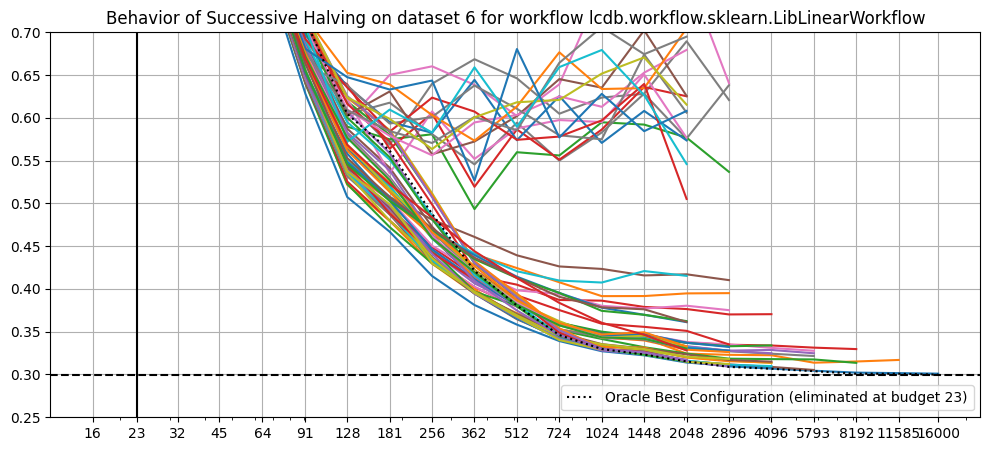

6 lcdb.workflow.sklearn.KNNWorkflow


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:46<00:00,  9.30s/it]


dropped best learning curve at budget 32.


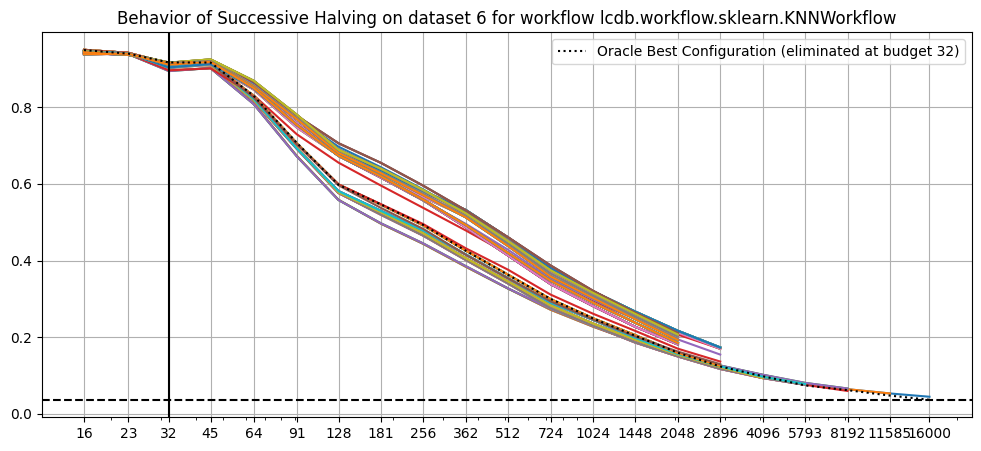

Skipping existing plot for openmlid 11 and workflow lcdb.workflow.sklearn.LibLinearWorkflow
Skipping existing plot for openmlid 11 and workflow lcdb.workflow.sklearn.LibSVMWorkflow
Skipping existing plot for openmlid 11 and workflow lcdb.workflow.sklearn.KNNWorkflow
Skipping existing plot for openmlid 12 and workflow lcdb.workflow.sklearn.LibLinearWorkflow
Skipping existing plot for openmlid 12 and workflow lcdb.workflow.sklearn.KNNWorkflow
Skipping existing plot for openmlid 14 and workflow lcdb.workflow.sklearn.LibLinearWorkflow
Skipping existing plot for openmlid 14 and workflow lcdb.workflow.sklearn.LibSVMWorkflow
Skipping existing plot for openmlid 14 and workflow lcdb.workflow.sklearn.KNNWorkflow


In [25]:
limits = {
    (6, "lcdb.workflow.sklearn.LibLinearWorkflow"): [0.25, 0.7],
    (11, "lcdb.workflow.sklearn.LibLinearWorkflow"): [0.08, 0.15],
    (11, "lcdb.workflow.sklearn.LibSVMWorkflow"): [0.0, 0.2],
    (11, "lcdb.workflow.sklearn.KNNWorkflow"): [0, 0.15],
    (12, "lcdb.workflow.sklearn.LibLinearWorkflow"): [0, 0.1],
    (12, "lcdb.workflow.sklearn.KNNWorkflow"): [0, 0.2],
    (14, "lcdb.workflow.sklearn.LibLinearWorkflow"): [0.15, 0.35],
    (14, "lcdb.workflow.sklearn.LibSVMWorkflow"): [0.1, 0.3],
    (14, "lcdb.workflow.sklearn.KNNWorkflow"): [0.15, 0.35]
}
for openmlid, workflow in it.product(
    [6, 11, 12, 14],
    ["lcdb.workflow.sklearn.LibLinearWorkflow", "lcdb.workflow.sklearn.LibSVMWorkflow", "lcdb.workflow.sklearn.KNNWorkflow"]
):
    if openmlid in [6, 12] and workflow == "lcdb.workflow.sklearn.LibSVMWorkflow":
        continue
    if not pathlib.Path(f"plots/successive_halving_{openmlid}_{workflow}.pdf").exists():
        print(openmlid, workflow)
        plot_successive_halving(openmlid=openmlid, workflow=workflow, y_lim=limits.get((openmlid, workflow), None))
    else:
        print(f"Skipping existing plot for openmlid {openmlid} and workflow {workflow}")